In [32]:
import tensorflow as tf
import pandas as pd
import keras
from sklearn.model_selection import train_test_split
from keras import *
from keras.src.layers import Dense, LeakyReLU, Dropout
import matplotlib.pyplot as plt
import numpy as np
import os

In [33]:
# Import model and data
from Resnet import model
from Input import train_data, val_data

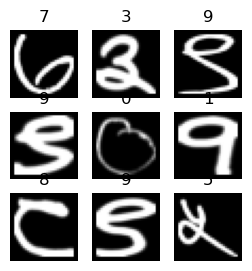

In [34]:
# Data Visualization

plt.figure(figsize=(3, 3))
for images, labels in train_data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow((images[i].numpy() * 255).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

In [ ]:
epochs = 11

callbacks = [
    keras.callbacks.ModelCheckpoint("Digits_ResNet_save_at_{epoch}.keras", save_freq='epoch', save_weights_only=True),
]

history = model.fit(
    train_data,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_data,
)

Epoch 1/11
425/425 [==============================] - 515s 1s/step - loss: 7.6252e-05 - accuracy: 1.0000 - val_loss: 0.0191 - val_accuracy: 0.9982
Epoch 2/11
425/425 [==============================] - 505s 1s/step - loss: 0.0034 - accuracy: 0.9987 - val_loss: 0.0207 - val_accuracy: 0.9976
Epoch 3/11
425/425 [==============================] - 519s 1s/step - loss: 0.0027 - accuracy: 0.9990 - val_loss: 0.0195 - val_accuracy: 0.9976
Epoch 4/11
425/425 [==============================] - 523s 1s/step - loss: 0.0022 - accuracy: 0.9993 - val_loss: 0.0241 - val_accuracy: 0.9979
Epoch 5/11
425/425 [==============================] - 481s 1s/step - loss: 7.9534e-04 - accuracy: 0.9999 - val_loss: 0.0164 - val_accuracy: 0.9976
Epoch 6/11
357/425 [========================>.....] - ETA: 1:09 - loss: 0.0027 - accuracy: 0.9989

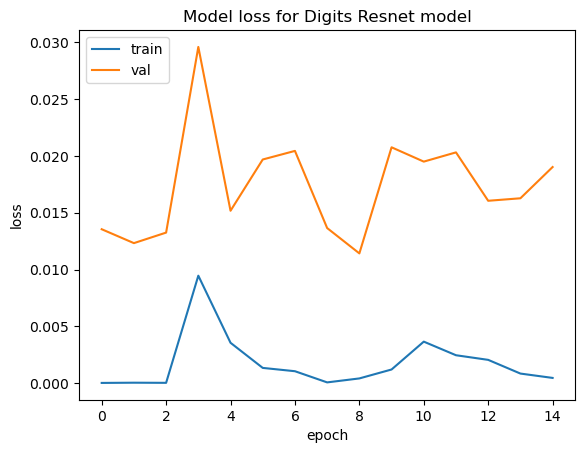

In [38]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss for Digits Resnet model')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

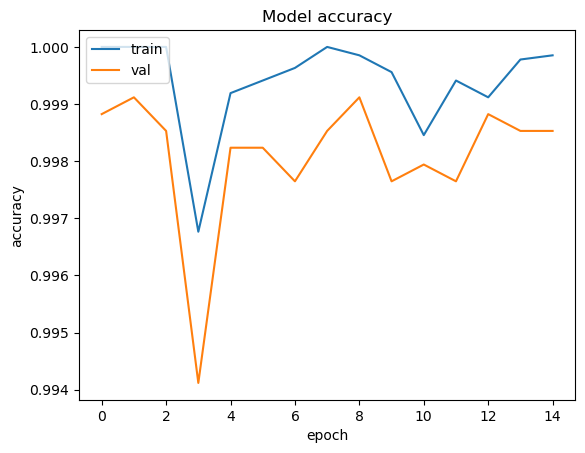

In [39]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [3]:
# Import and run test evaluation
from importlib import reload
import test
reload(test)

# Specify which epoch to evaluate (change this to test different checkpoints)
chosen_epoch = 1

# Run evaluation
results_df = test.evaluate_model(chosen_epoch)
print(f"\nEvaluation complete using epoch {chosen_epoch}")
print(f"Sample predictions:\n{results_df.head(10)}")

Loading weights from Digits_ResNet_save_at_1.keras
94/94 [==============================] - 21s 219ms/step
Predictions from epoch 1 saved to submission.csv

Evaluation complete using epoch 1
Sample predictions:
      Id  Category
0  56604         6
1  29396         3
2  43803         6
3  12313         0
4  10341         8
5  40355         3
6  41117         4
7  71324         7
8   6854         1
9  12761         8
